In [ ]:
!pip install datasets   # Load dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset("imdb")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [ ]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [ ]:
import pandas as pd

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


In [ ]:
print("Train size:", len(train_df))
print("Test size:", len(test_df))

print("\nTrain label dağılımı:")
print(train_df["label"].value_counts())

Train size: 25000
Test size: 25000

Train label dağılımı:
label
0    12500
1    12500
Name: count, dtype: int64


In [ ]:
train_df = train_df.sample(5000, random_state=42)
test_df = test_df.sample(1000, random_state=42)

print("Yeni train size:", len(train_df))
print("Yeni test size:", len(test_df))

Yeni train size: 5000
Yeni test size: 1000


In [ ]:
import re

def clean_text(text):
    text = text.lower()                        # küçük harfe çevir
    text = re.sub(r'<.*?>', '', text)          # <br /> gibi HTML tagları sil
    text = re.sub(r'[^a-z0-9\s]', '', text)   # noktalama işaretlerini sil
    text = re.sub(r'\s+', ' ', text).strip()  # fazla boşlukları sil
    return text

train_df['text'] = train_df['text'].apply(clean_text)
test_df['text'] = test_df['text'].apply(clean_text)

print("Temizleme tamamlandı!")
print("\nÖrnek temizlenmiş metin:")
print(train_df['text'].iloc[0][:300])

Temizleme tamamlandı!

Örnek temizlenmiş metin:
dumb is as dumb does in this thoroughly uninteresting supposed black comedy essentially what starts out as chris klein trying to maintain a low profile eventually morphs into an uninspired version of the three amigos only without any laughs in order for black comedy to work it must be outrageous whi


In [ ]:
def clean_text_distilbert(text):
    text = re.sub(r'<.*?>', '', text)          # sadece HTML tagları sil
    text = re.sub(r'\s+', ' ', text).strip()   # fazla boşlukları sil
    return text

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])

y_train = train_df["label"]
y_test = test_df["label"]

print("Geliştirilmiş TF-IDF tamamlandı")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Geliştirilmiş TF-IDF tamamlandı
X_train shape: (5000, 10000)
X_test shape: (1000, 10000)


In [ ]:
import torch

# sparse matrix → normal array → tensor
X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("Tensor dönüşümü tamam")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

Tensor dönüşümü tamam
X_train_tensor: torch.Size([5000, 10000])
y_train_tensor: torch.Size([5000, 1])


In [ ]:
import torch.nn as nn

class SentimentNet(nn.Module):
    def __init__(self, input_size):
        super(SentimentNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

input_size = X_train_tensor.shape[1]
model = SentimentNet(input_size)

print(model)

SentimentNet(
  (fc1): Linear(in_features=10000, out_features=256, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
import torch.optim as optim

# Modeli ve optimizer'ı sıfırla
model = SentimentNet(input_size)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# Validation split ekle
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_tensor, y_train_tensor, test_size=0.1, random_state=42
)

train_dataset = TensorDataset(X_train_final, y_train_final)
val_dataset = TensorDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

num_epochs = 5
loss_history = []
val_loss_history = []

# Early stopping ayarları
best_val_loss = float('inf')
patience = 2          # kaç epoch arka arkaya kötüleşirse dur
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Early stopping kontrolü
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()  # en iyi modeli kaydet
        print(f"  ✓ Val loss iyileşti, model kaydedildi.")
    else:
        patience_counter += 1
        print(f"  ✗ Val loss iyileşmedi. ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"\nEarly stopping! En iyi val loss: {best_val_loss:.4f}")
            break

# En iyi model ağırlıklarını geri yükle
model.load_state_dict(best_model_state)
print("En iyi model yüklendi.")


Epoch 1/5, Train Loss: 0.4881, Val Loss: 0.3648
  ✓ Val loss iyileşti, model kaydedildi.
Epoch 2/5, Train Loss: 0.1227, Val Loss: 0.3831
  ✗ Val loss iyileşmedi. (1/2)
Epoch 3/5, Train Loss: 0.0261, Val Loss: 0.4544
  ✗ Val loss iyileşmedi. (2/2)

Early stopping! En iyi val loss: 0.3648
En iyi model yüklendi.


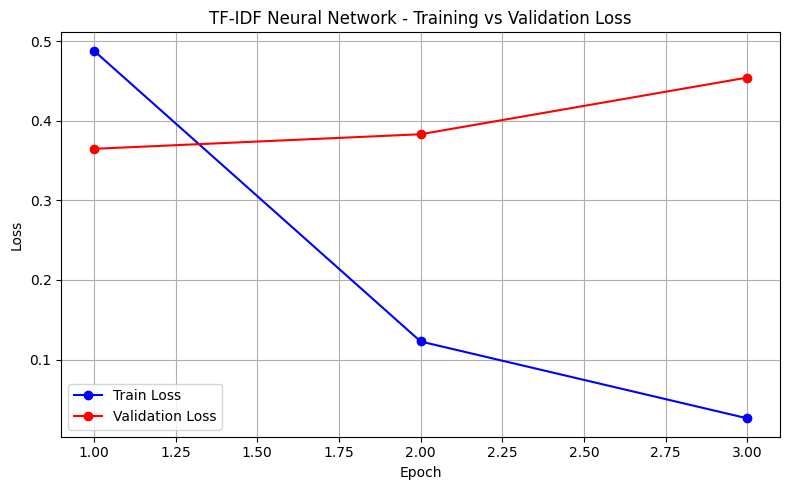

In [ ]:
import matplotlib.pyplot as plt

actual_epochs = len(loss_history)  # early stopping kaçta durduysa o kadar

plt.figure(figsize=(8, 5))
plt.plot(range(1, actual_epochs+1), loss_history, marker='o', color='blue', label='Train Loss')
plt.plot(range(1, actual_epochs+1), val_loss_history, marker='o', color='red', label='Validation Loss')
plt.title('TF-IDF Neural Network - Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

model.eval()

with torch.no_grad():
    test_outputs = model(X_test_tensor)
    predictions = (test_outputs >= 0.5).float()

accuracy = accuracy_score(y_test_tensor, predictions)
print("Test Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test_tensor, predictions))

Test Accuracy: 0.841

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.87      0.85       511
         1.0       0.86      0.81      0.83       489

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



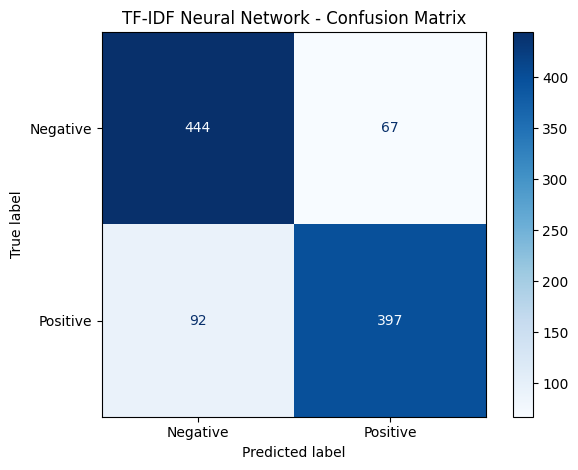

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test_tensor, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues")
plt.title("TF-IDF Neural Network - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

def predict_sentiment(text):
    # Temizle
    cleaned = clean_text(text)

    # TF-IDF'e çevir
    vectorized = vectorizer.transform([cleaned])
    tensor = torch.tensor(vectorized.toarray(), dtype=torch.float32)

    # Tahmin yap
    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probability = output.item()
        prediction = "Positive 😊" if probability >= 0.5 else "Negative 😞"
        confidence = probability if probability >= 0.5 else 1 - probability

    return f"{prediction} (Confidence: {confidence:.1%})"

# Gradio arayüzü
app = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Write a movie review here...",
        label="Movie Review"
    ),
    outputs=gr.Textbox(label="Sentiment"),
    title="🎬 Sentiment Analysis App",
    description="Enter a movie review and the model will predict if it's Positive or Negative."
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://68e78a7ee6c3437f22.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install transformers

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

# Tokenizer ve model yükle
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

print("Tokenizer yüklendi!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer yüklendi!


In [ ]:
# Eğitim ve test metinlerini tokenize et
def tokenize_data(texts, labels, max_length=256):
    encodings = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt"
    )
    return encodings, torch.tensor(list(labels), dtype=torch.long)

# DistilBERT için orijinal dataset'ten temiz metin al (HTML tag'ları sil, lowercase yapma)
train_df_raw = pd.DataFrame(dataset["train"]).sample(5000, random_state=42)
test_df_raw  = pd.DataFrame(dataset["test"]).sample(1000, random_state=42)

train_df_raw['text_distilbert'] = train_df_raw['text'].apply(clean_text_distilbert)
test_df_raw['text_distilbert']  = test_df_raw['text'].apply(clean_text_distilbert)

train_encodings, train_labels = tokenize_data(train_df_raw["text_distilbert"], train_df_raw["label"])
test_encodings, test_labels   = tokenize_data(test_df_raw["text_distilbert"],  test_df_raw["label"])

print("Tokenization tamamlandı!")
print("Train shape:", train_encodings["input_ids"].shape)
print("Test shape:", test_encodings["input_ids"].shape)


Tokenization tamamlandı!
Train shape: torch.Size([5000, 256])
Test shape: torch.Size([1000, 256])


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Dataset oluştur
train_dataset = TensorDataset(
    train_encodings["input_ids"],
    train_encodings["attention_mask"],
    train_labels
)

test_dataset = TensorDataset(
    test_encodings["input_ids"],
    test_encodings["attention_mask"],
    test_labels
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print("DataLoader hazır!")
print("Train batch sayısı:", len(train_loader))

DataLoader hazır!
Train batch sayısı: 313


In [ ]:
from transformers import AutoModelForSequenceClassification

# DistilBERT modelini yükle
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

# GPU'ya taşı
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
distilbert_model = distilbert_model.to(device)

print("Model yüklendi!")
print("Kullanılan cihaz:", device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model yüklendi!
Kullanılan cihaz: cuda


In [ ]:
from torch.optim import AdamW
from torch.utils.data import random_split

optimizer = AdamW(distilbert_model.parameters(), lr=2e-5)

# Validation split - train'in %10'u
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_sub, val_sub = random_split(train_dataset, [train_size, val_size])

train_loader_bert = DataLoader(train_sub, batch_size=16, shuffle=True)
val_loader_bert = DataLoader(val_sub, batch_size=16)

num_epochs = 3
distilbert_loss_history = []
distilbert_val_loss_history = []

# Early stopping ayarları
best_val_loss_bert = float('inf')
patience_bert = 1          # transformer'lar için 1 yeterli
patience_counter_bert = 0
best_model_state_bert = None

for epoch in range(num_epochs):
    # --- Training ---
    distilbert_model.train()
    total_loss = 0
    for batch in train_loader_bert:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = distilbert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader_bert)
    distilbert_loss_history.append(avg_loss)

    # --- Validation ---
    distilbert_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader_bert:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = distilbert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()
    avg_val_loss = val_loss / len(val_loader_bert)
    distilbert_val_loss_history.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Early stopping kontrolü
    if avg_val_loss < best_val_loss_bert:
        best_val_loss_bert = avg_val_loss
        patience_counter_bert = 0
        distilbert_model.save_pretrained('distilbert_best')
        tokenizer.save_pretrained('distilbert_best')
        print(f"  ✓ Val loss iyileşti, model kaydedildi.")
    else:
        patience_counter_bert += 1
        print(f"  ✗ Val loss iyileşmedi. ({patience_counter_bert}/{patience_bert})")
        if patience_counter_bert >= patience_bert:
            print(f"\nEarly stopping! En iyi val loss: {best_val_loss_bert:.4f}")
            break

# En iyi modeli geri yükle
from transformers import AutoModelForSequenceClassification
distilbert_model = AutoModelForSequenceClassification.from_pretrained('distilbert_best').to(device)
print("En iyi DistilBERT modeli yüklendi.")


Epoch 1/3, Train Loss: 0.3576, Val Loss: 0.2277


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Val loss iyileşti, model kaydedildi.
Epoch 2/3, Train Loss: 0.1807, Val Loss: 0.2715
  ✗ Val loss iyileşmedi. (1/1)

Early stopping! En iyi val loss: 0.2277


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

En iyi DistilBERT modeli yüklendi.


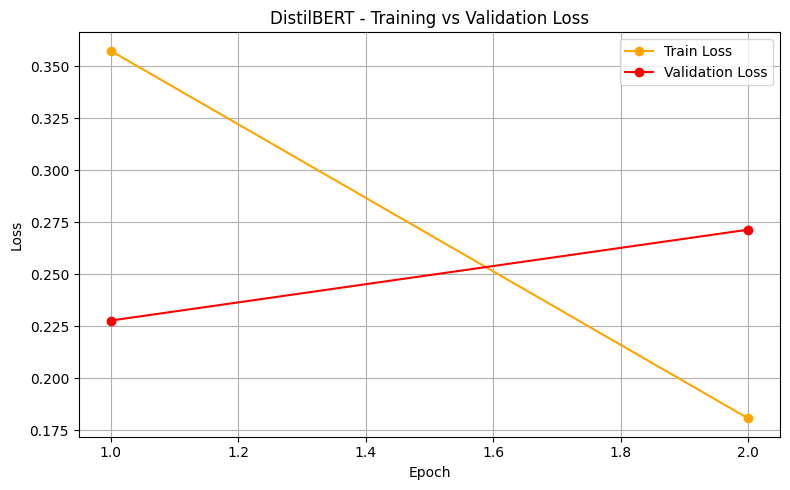

In [ ]:
import matplotlib.pyplot as plt

actual_epochs_bert = len(distilbert_loss_history)  # early stopping kaçta durduysa o kadar

plt.figure(figsize=(8, 5))
plt.plot(range(1, actual_epochs_bert+1), distilbert_loss_history, marker='o', color='orange', label='Train Loss')
plt.plot(range(1, actual_epochs_bert+1), distilbert_val_loss_history, marker='o', color='red', label='Validation Loss')
plt.title('DistilBERT - Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

distilbert_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = distilbert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print("DistilBERT Test Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

DistilBERT Test Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       511
           1       0.94      0.85      0.89       489

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



In [ ]:
import pickle

# TF-IDF modelini kaydet
torch.save(model.state_dict(), 'tfidf_model.pth')
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# DistilBERT modelini kaydet
distilbert_model.save_pretrained('distilbert_sentiment')
tokenizer.save_pretrained('distilbert_sentiment')

print("Modeller kaydedildi!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modeller kaydedildi!


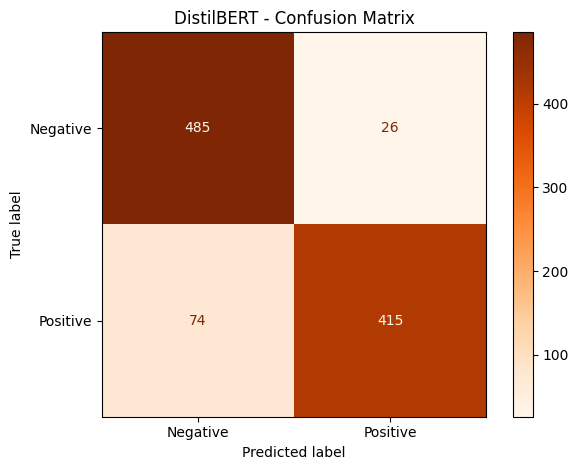

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Oranges")
plt.title("DistilBERT - Confusion Matrix")
plt.tight_layout()
plt.show()

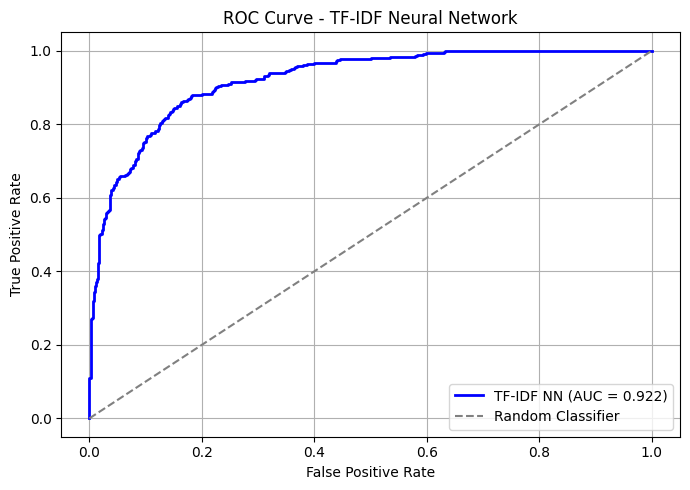

TF-IDF Neural Network ROC-AUC: 0.9222


In [ ]:
# ROC-AUC Curve - TF-IDF Neural Network
from sklearn.metrics import roc_curve, auc

model.eval()
with torch.no_grad():
    tfidf_probs = model(X_test_tensor).squeeze().numpy()

fpr_tfidf, tpr_tfidf, _ = roc_curve(y_test_tensor.numpy(), tfidf_probs)
roc_auc_tfidf = auc(fpr_tfidf, tpr_tfidf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_tfidf, tpr_tfidf, color='blue', lw=2, label=f'TF-IDF NN (AUC = {roc_auc_tfidf:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - TF-IDF Neural Network')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"TF-IDF Neural Network ROC-AUC: {roc_auc_tfidf:.4f}")


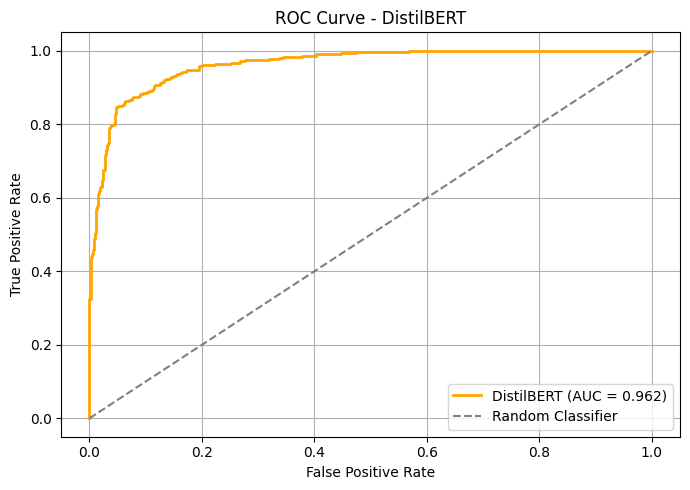

DistilBERT ROC-AUC: 0.9620


In [ ]:
# ROC-AUC Curve - DistilBERT
import numpy as np
from sklearn.metrics import roc_curve, auc

distilbert_model.eval()
all_probs = []
all_true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = distilbert_model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]  # Positive sınıfı olasılığı
        all_probs.extend(probs.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

fpr_bert, tpr_bert, _ = roc_curve(all_true_labels, all_probs)
roc_auc_bert = auc(fpr_bert, tpr_bert)

plt.figure(figsize=(7, 5))
plt.plot(fpr_bert, tpr_bert, color='orange', lw=2, label=f'DistilBERT (AUC = {roc_auc_bert:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DistilBERT')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"DistilBERT ROC-AUC: {roc_auc_bert:.4f}")


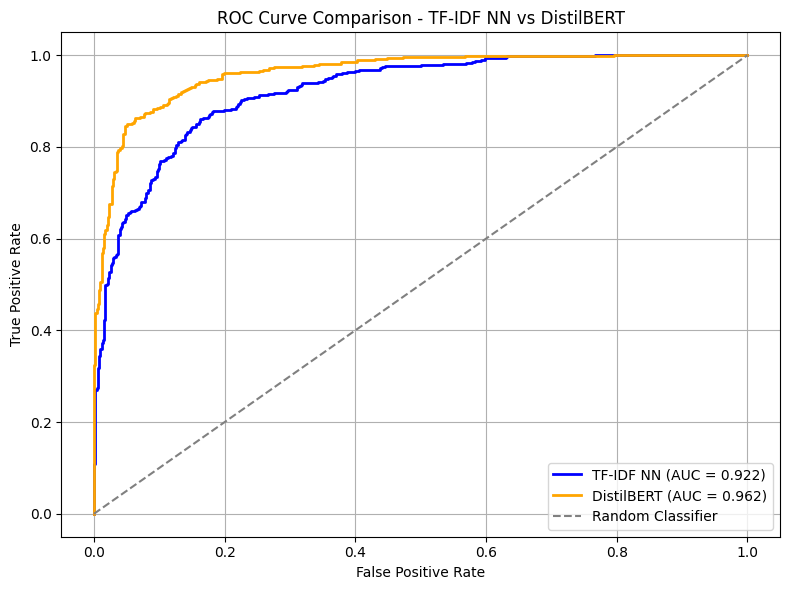


Model Karşılaştırması:
TF-IDF Neural Network AUC: 0.9222
DistilBERT             AUC: 0.9620
DistilBERT farkı:     +0.0398


In [ ]:
# İki Modelin ROC Curve Karşılaştırması
plt.figure(figsize=(8, 6))
plt.plot(fpr_tfidf, tpr_tfidf, color='blue', lw=2, label=f'TF-IDF NN (AUC = {roc_auc_tfidf:.3f})')
plt.plot(fpr_bert, tpr_bert, color='orange', lw=2, label=f'DistilBERT (AUC = {roc_auc_bert:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - TF-IDF NN vs DistilBERT')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nModel Karşılaştırması:")
print(f"TF-IDF Neural Network AUC: {roc_auc_tfidf:.4f}")
print(f"DistilBERT             AUC: {roc_auc_bert:.4f}")
print(f"DistilBERT farkı:     +{roc_auc_bert - roc_auc_tfidf:.4f}")


In [ ]:
import gradio as gr

def predict_distilbert(text):
    cleaned = clean_text_distilbert(text)
    inputs = tokenizer(
        cleaned,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    distilbert_model.eval()
    with torch.no_grad():
        outputs = distilbert_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()

    label = "Positive 😊" if pred == 1 else "Negative 😞"
    return f"{label} (Confidence: {confidence:.1%})"

app2 = gr.Interface(
    fn=predict_distilbert,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Write a movie review here...",
        label="Movie Review"
    ),
    outputs=gr.Textbox(label="Sentiment"),
    title="🎬 Sentiment Analysis - DistilBERT",
    description="Advanced transformer-based sentiment analysis. Enter a movie review to classify it."
)

app2.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2db4454467b7c118f8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
